In [4]:
import os.path as op
import numpy as np
import os
import pandas as pd

In [22]:
from utils import plot_nets_CAcolors

sub = 'All'
sessions = '1-2'
tasks = 'magjudge-placevalue-rest'
conn_thresholds = [0.03, 0.04, 0.05, 0.1, 0.2, 0.4] 
conn_thresholds_string = "-".join([str(t) for t in conn_thresholds])

bids_folder = '/mnt_AdaBD_largefiles/Data/DNumRisk_Data/ds-smile'
target_folder = op.join(bids_folder,'derivatives','networks_infomap', f'sub-{sub}')
plot_folder = op.join(bids_folder,'plots_and_ims','networks_infomap')

fn_consens_mapping = op.join(target_folder, f'sub-{sub}_ses-{sessions}_task-{tasks}_threshs-{conn_thresholds_string}_precFuncMaps-consensMap.npy')
consens_mapping = np.load(fn_consens_mapping)

from numrisk.fmri_analysis.gradients.utils import get_basic_mask
mask, _ = get_basic_mask()
modules_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
modules_fsav5[mask] = consens_mapping

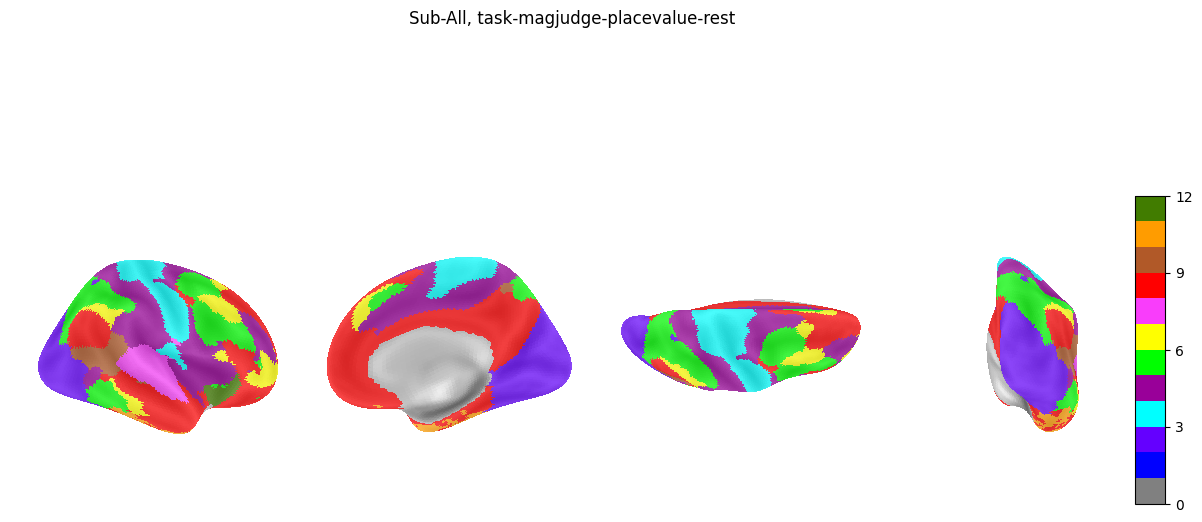

In [23]:
from utils import plot_nets_CAcolors


figure = plot_nets_CAcolors(modules_fsav5, hemi_to_plot='R', title=f'Sub-{sub}, task-{tasks}')
plot_fn = op.join(plot_folder, f'sub-{sub}_ses-{sessions}_task-{tasks}_hemi-R_precFuncMaps-consensMap.png')
figure.savefig(plot_fn, dpi=300, bbox_inches='tight')

In [19]:
fn_mappings = op.join(target_folder, f'sub-{sub}_ses-{sessions}_task-{tasks}_threshs-{conn_thresholds_string}_precFuncMaps-allThresholds.npy')
all_thresh_maps = np.load(fn_mappings)
print(f'All thresholds mappings shape: {all_thresh_maps.shape}')  # (n_vertices, n_thresholds)

All thresholds mappings shape: (6, 18715)


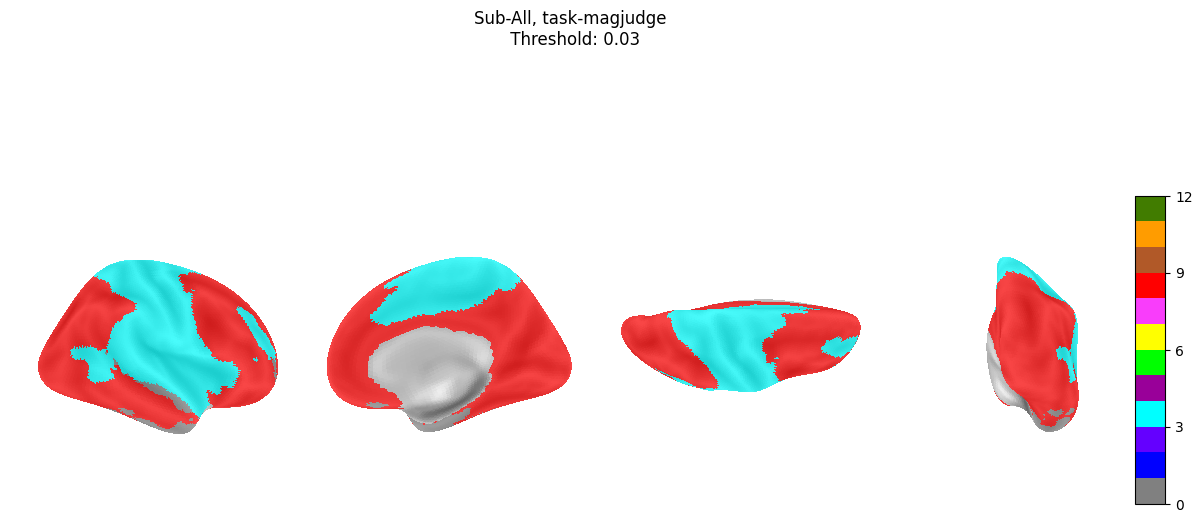

In [21]:
thesh_i = 0
modules_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
modules_fsav5[mask] = all_thresh_maps[thesh_i]

figure = plot_nets_CAcolors(modules_fsav5, hemi_to_plot='R', title=f'Sub-{sub}, task-{tasks} \n Threshold: {conn_thresholds[thesh_i]}')


## Basic Functions


In [ ]:
from numrisk.fmri_analysis.gradients.utils import get_basic_mask
mask, labeling_noParcel = get_basic_mask()

from numrisk.fmri_analysis.gradients.utils import get_glasser_CAatlas_mapping, get_glasser_parcels
mask_glasser, labeling_glasser = get_glasser_parcels(space = 'fsaverage5' )
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

from brainspace.utils.parcellation import map_to_labels
caNets_fsav5_mapping = map_to_labels(glasser_CAatlas_mapping['ca_network'].values , 
                                     labeling_glasser, mask=mask_glasser, fill=0) #, fill=np.nan) #grad_sub[n_grad-1]

print(caNets_fsav5_mapping.shape)
target_folder = op.join(bids_folder,'derivatives','networks_infomap')
os.makedirs(target_folder, exist_ok=True)

np.save(op.join(target_folder, 'caNets_fsaverage5_mapping.npy'), caNets_fsav5_mapping[mask])



(20484,)


In [24]:
bids_folder = '/mnt_AdaBD_largefiles/Data/DNumRisk_Data/ds-smile'
sub = 'All'
sessions = '1-2'
tasks = 'magjudge'

source_folder = op.join(bids_folder, 'derivatives', 'correlation_matrices', f'sub-{sub}')


# Load in CM
cm_fn = op.join(source_folder, f'sub-{sub}_ses-{sessions}_task-{tasks}_funcCM.npy')
cm_f = np.load(cm_fn)

print(cm_f.shape)

(18715, 18715)


In [38]:
from fit_precFuncMap_01 import assign_subject_communities_to_reference, spatial_filtering,threshold_matrix

cm_filtered = spatial_filtering(cm_f, bids_folder=bids_folder)
conn_threshold = 0.1
preferred_number_of_modules = 17

from infomap import Infomap
cm_thresh = threshold_matrix(cm_filtered, proportion=conn_threshold)
N = cm_thresh.shape[0]
im = Infomap(preferred_number_of_modules=preferred_number_of_modules) # add flags like '--two-level' if needed
for i in range(N):
    for j in range(i+1, N):
        w = cm_thresh[i, j]
        if w > 0:
            im.add_link(i, j, w)
im.run()


  Infomap v2.8.0 starts at 2025-12-05 13:30:28
  -> Input network: 
  -> No file output!
  -> Configuration: preferred-number-of-modules = 17
  OpenMP 201511 detected with 16 threads...
  -> Ordinary network input, using the Map Equation for first order network flows
Calculating global network flow using flow model 'undirected'... 
  -> Using undirected links.
  => Sum node flow: 1, sum link flow: 1
Build internal network with 18426 nodes and 8425830 links...
  -> One-level codelength: 13.7943966

Trial 1/1 starting at 2025-12-05 13:30:34
Two-level compression: 8% 0.38% 0.00983195788% 0.00900965916% 
Partitioned to codelength 0.552259703 + 12.0947189 + 0 = 12.64697865 in 17 (14 non-trivial) modules.

Recursive sub-structure compression: 0% . Found 2 levels with codelength 12.64697865

=> Trial 1/1 finished in 44.6659686s with codelength 12.6469786


Summary after 1 trial
Best end modular solution in 2 levels:
Per level number of modules:         [         17,           0] (sum: 17)
Per

In [39]:
ref_fn = op.join(bids_folder,'derivatives','networks_infomap', 'caNets_fsaverage5_mapping.npy')
target_labels_caNets = np.load(ref_fn)


returned_nodes = np.array([node.node_id for node in im.nodes])
returned_modules = np.array([node.module_id for node in im.nodes])
full_module_mapping = np.full((N,), -1, dtype=int)  # -1 means unassigned
full_module_mapping[returned_nodes] = returned_modules

relabeled_subject, assignments = assign_subject_communities_to_reference(full_module_mapping, target_labels_caNets,  jaccard_threshold=0.1)


In [41]:
ref_fn

'/mnt_AdaBD_largefiles/Data/DNumRisk_Data/ds-smile/derivatives/networks_infomap/caNets_fsaverage5_mapping.npy'

In [42]:
ref_name = 'dnumrisk-average'
fn_target_labels_caNets = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/networks_infomap_full_01/sub-average_consensusMapping_confspec-36Pscrub3BPfilter.npy'

target_labels_caNets = np.load(fn_target_labels_caNets)
relabeled_subject, assignments = assign_subject_communities_to_reference(full_module_mapping, target_labels_caNets,  jaccard_threshold=0.1)


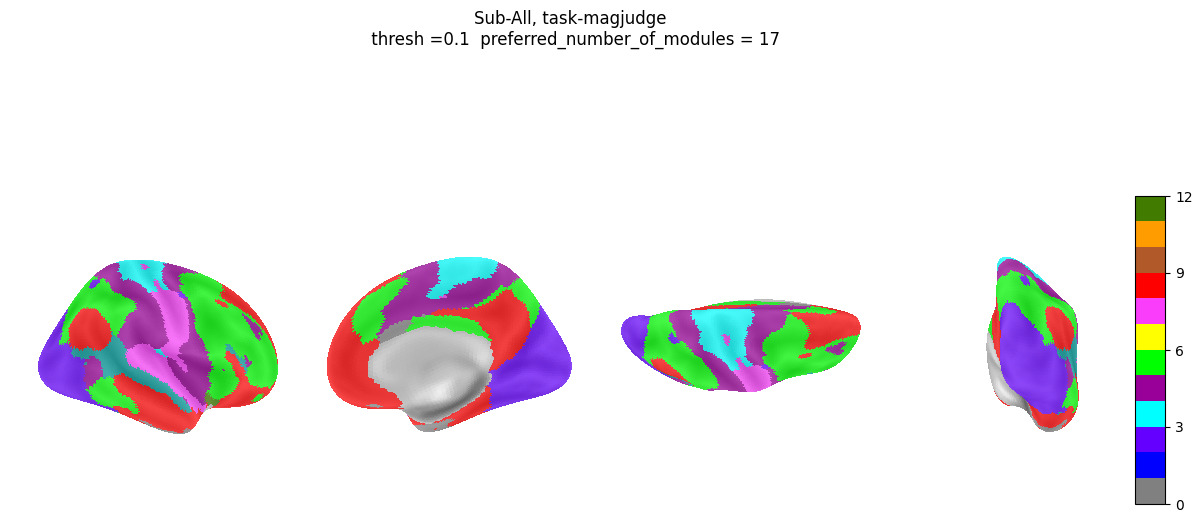

In [43]:
modules_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
modules_fsav5[mask] =relabeled_subject

figure = plot_nets_CAcolors(modules_fsav5, hemi_to_plot='R', 
        title=f'Sub-{sub}, task-{tasks} \n thresh ={conn_threshold}  preferred_number_of_modules = {preferred_number_of_modules}')
plot_fn = op.join(plot_folder, f'sub-{sub}',
    f'sub-{sub}_ses-{sessions}_task-{tasks}_hemi-R_precFuncMaps-consensMap.png')
figure.savefig(plot_fn, dpi=300, bbox_inches='tight')


## Gradient coordinate space + network colors

In [ ]:
sub = 'average-dnumrisk'

base_folder = '/mnt_AdaBD_largefiles/Data/DNumRisk_Data/connectivity_references'
gms = np.load(op.join(base_folder, 'dataset-dnumrisk_sub-All_gradients_kernel-normalized_angle_ztransf-True_avMethod-tanH.npy'))




In [ ]:
atlas_spec = 'dnumrisk-magjudge-precFuncMap'

net_map =  np.load(op.join(base_folder, 'dataset-dnumrisk_sub-All_consensusMapping.npy'))

In [ ]:
atlas_spec = 'ColeAnticevic standard'

ref_fn = op.join(base_folder, 'caNets_fsaverage5_mapping.npy') 
net_map = np.load(ref_fn)

In [17]:
np.shape(nets_fsav5)

(18715,)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import hcp_utils as hcp
rgb = np.array(list(hcp.ca_network['rgba'].values())[1:])
grey = np.array([[0.5, 0.5, 0.5, 1.0]])  # RGBA format: grey with full opacity
cmap_ca = ListedColormap( np.vstack([grey, rgb]))

from utils import get_basic_mask
mask, _ = get_basic_mask()
nets_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
nets_fsav5[mask] = net_map
df = pd.DataFrame({'g1': gms[0, :], 'g2': gms[1, :],'g3': gms[2, :],'nets': nets_fsav5})

fig, axs = plt.subplots(1,3,figsize=(12,3))
sns.scatterplot(df, x='g2', y='g1', hue='nets',palette=cmap_ca,s=4, legend=False, hue_order=range(1, 13), hue_norm=plt.Normalize(0, 12), ax=axs[0], alpha=0.3) #vmin = 0, vmax=12)#
sns.scatterplot(df, x='g3', y='g1', hue='nets',palette=cmap_ca,s=4, legend=False, hue_order=range(1, 13), hue_norm=plt.Normalize(0, 12), ax=axs[1], alpha=0.3) #vmin = 0, vmax=12)#
sns.scatterplot(df, x='g3', y='g2', hue='nets',palette=cmap_ca,s=4, legend=False, hue_order=range(1, 13), hue_norm=plt.Normalize(0, 12), ax=axs[2], alpha=0.3) #vmin = 0, vmax=12)#
fig.suptitle(f'sub-{sub}, atlas {atlas_spec}', fontsize=16)
sns.despine()

ValueError: All arrays must be of the same length